# Анализ данных маркетплейса (Olist)

## Цель проекта
Проанализировать транзакционные данные маркетплейса для оценки:
- динамики заказов
- выручки
- среднего чека (AOV)
- повторных покупок
- качества доставки

Выручка измеряется в BRL (бразильские реалы).

---

## Структура анализа
1. Загрузка и проверка данных  
2. Динамика заказов  
3. Выручка и средний чек  
4. Анализ доставки  
5. Повторные покупки  
6. Ключевые выводы

In [10]:
import pandas as pd
import matplotlib.pyplot as plt

plt.style.use("seaborn-v0_8")

# Загружаем основные таблицы
orders = pd.read_csv("../data/olist_orders_dataset.csv")
order_items = pd.read_csv("../data/olist_order_items_dataset.csv")
payments = pd.read_csv("../data/olist_order_payments_dataset.csv")
customers = pd.read_csv("../data/olist_customers_dataset.csv")

print("Размеры таблиц:")
print("orders:", orders.shape)
print("order_items:", order_items.shape)
print("payments:", payments.shape)
print("customers:", customers.shape)

Размеры таблиц:
orders: (99441, 8)
order_items: (112650, 7)
payments: (103886, 5)
customers: (99441, 5)


In [11]:
# Преобразуем даты в формат datetime
orders["order_purchase_timestamp"] = pd.to_datetime(orders["order_purchase_timestamp"])
orders["order_delivered_customer_date"] = pd.to_datetime(orders["order_delivered_customer_date"])
orders["order_estimated_delivery_date"] = pd.to_datetime(orders["order_estimated_delivery_date"])

## Динамика заказов по месяцам
Оценим изменение количества заказов во времени.

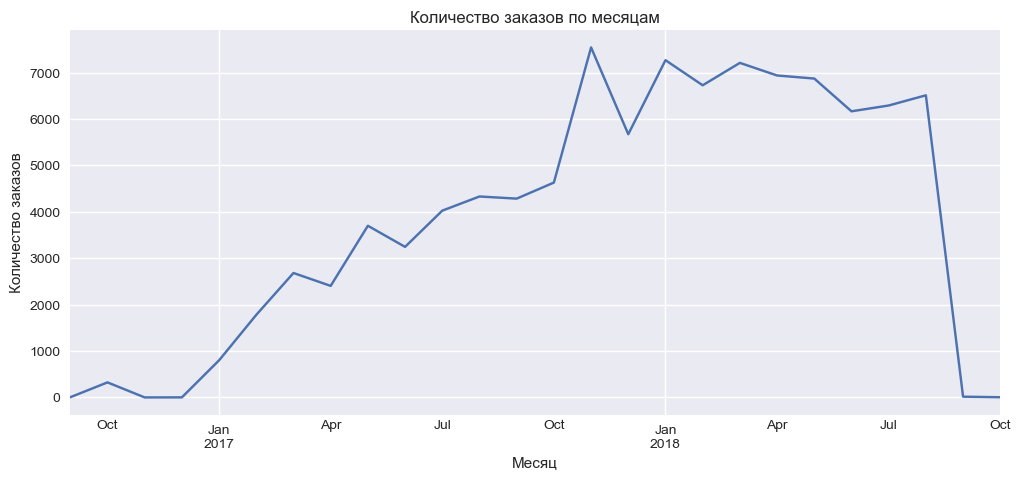

In [12]:
orders_per_month = (
    orders.set_index("order_purchase_timestamp")
    .resample("ME")
    .size()
)

orders_per_month.plot(figsize=(12,5))
plt.title("Количество заказов по месяцам")
plt.xlabel("Месяц")
plt.ylabel("Количество заказов")
plt.show()

## Выручка и средний чек (AOV)

Выручка рассчитывается на основе payment_value.
AOV = средняя сумма оплаты одного заказа.

In [13]:
# Суммируем оплату по каждому заказу
df_pay = payments.groupby("order_id", as_index=False)["payment_value"].sum()

total_revenue = df_pay["payment_value"].sum()
aov = df_pay["payment_value"].mean()

print(f"Общая выручка: {total_revenue:,.2f} BRL")
print(f"Средний чек (AOV): {aov:.2f} BRL")

Общая выручка: 16,008,872.12 BRL
Средний чек (AOV): 160.99 BRL


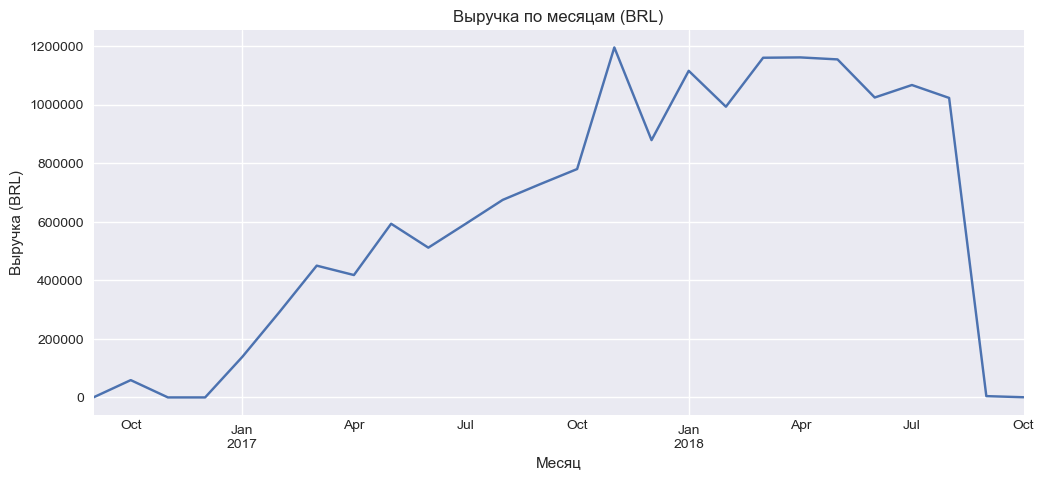

In [16]:
rev_month = (
    orders[["order_id", "order_purchase_timestamp"]]
    .merge(df_pay, on="order_id", how="inner")
)

rev_month = (
    rev_month
    .set_index("order_purchase_timestamp")
    .resample("ME")["payment_value"]
    .sum()
)

rev_month.plot(figsize=(12,5))
plt.title("Выручка по месяцам (BRL)")
plt.xlabel("Месяц")
plt.ylabel("Выручка (BRL)")
plt.ticklabel_format(style='plain', axis='y')
plt.show()

## Анализ доставки

Рассчитаем:
- среднее время доставки
- долю заказов с задержкой

In [17]:
# Время доставки в днях
orders["delivery_time_days"] = (
    orders["order_delivered_customer_date"] -
    orders["order_purchase_timestamp"]
).dt.days

# Флаг задержки
orders["is_delayed"] = (
    orders["order_delivered_customer_date"] >
    orders["order_estimated_delivery_date"]
)

avg_delivery = orders["delivery_time_days"].mean()
delay_rate = orders["is_delayed"].mean()

print(f"Среднее время доставки: {avg_delivery:.2f} дней")
print(f"Доля заказов с задержкой: {delay_rate:.2%}")

Среднее время доставки: 12.09 дней
Доля заказов с задержкой: 7.87%


## Повторные покупки

Оценим долю клиентов, совершивших более одного заказа.

In [18]:
cust_orders = orders.merge(
    customers[["customer_id", "customer_unique_id"]],
    on="customer_id",
    how="left"
)

orders_per_customer = cust_orders.groupby("customer_unique_id")["order_id"].nunique()
repeat_rate = (orders_per_customer > 1).mean()

print(f"Доля повторных покупателей: {repeat_rate:.2%}")

Доля повторных покупателей: 3.12%


## Ключевые выводы

- Общая выручка: **16,008,872.12 BRL**
- Средний чек (AOV): **160.99 BRL**
- Пик продаж приходится на конец 2017 года (сезонный эффект).
- Доля повторных покупателей составляет **3.12%** — потенциал для развития retention-стратегии.
- Доля задержек доставки — **7.87%**, что может влиять на удовлетворенность клиентов.
- Резкое падение в конце периода связано с неполным последним месяцем данных.

---

## Бизнес-интерпретация

1. Необходимо развивать программы удержания клиентов.
2. Стоит проанализировать причины задержек доставки.
3. Сезонные пики можно использовать для усиления маркетинговых кампаний.